In [56]:
import pickle
import os
from tqdm import tqdm

# with open('../sim_res/buff/gaps_stats.pkl', 'rb') as f:
#     stats = pickle.load(f)

with open('../sim_res/buff/gaps_stats_with_nash_data.pkl', 'rb') as f:
    gaps_stats_with_nash_data = pickle.load(f)

stats = gaps_stats_with_nash_data

Improved by buffer: 0 / 238


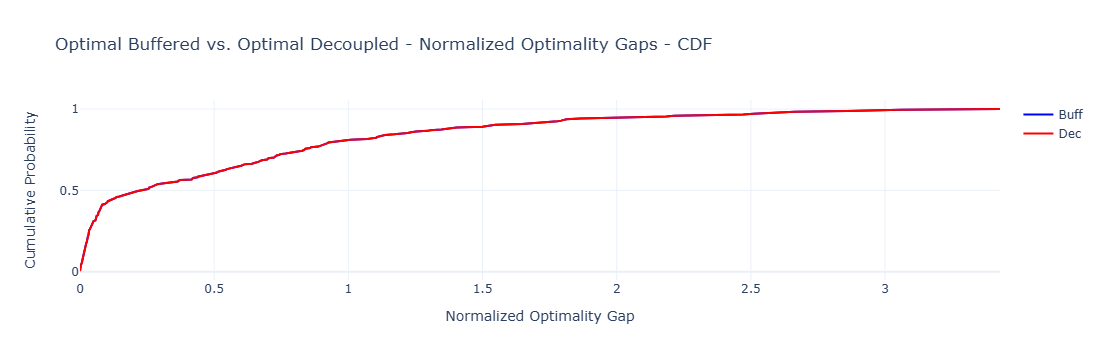

In [57]:
from matplotlib import pyplot as plt
import numpy as np
import plotly.graph_objects as go

# display stats
print(f"Improved by buffer: {sum(stats['improved_by_buffer'])} / {len(stats['improved_by_buffer'])}")

buff_gaps_normalized = stats['buff_gaps_normalized']
dec_gaps_normalized = stats['dec_gaps_normalized']


# Compute CDFs
buff_gaps_normalized_sorted = np.sort(buff_gaps_normalized)
dec_gaps_normalized_sorted = np.sort(dec_gaps_normalized)

cdf1 = np.arange(1, len(buff_gaps_normalized_sorted) + 1) / len(buff_gaps_normalized_sorted)
cdf2 = np.arange(1, len(dec_gaps_normalized_sorted) + 1) / len(dec_gaps_normalized_sorted)

# Create figure
fig = go.Figure()

fig.add_trace(go.Scatter(x=buff_gaps_normalized_sorted, y=cdf1, mode='lines', name="Buff", line=dict(color='blue')))
fig.add_trace(go.Scatter(x=dec_gaps_normalized_sorted, y=cdf2, mode='lines', name="Dec", line=dict(color='red')))

# Layout
fig.update_layout(title="Optimal Buffered vs. Optimal Decoupled - Normalized Optimality Gaps - CDF",
                  xaxis_title="Normalized Optimality Gap",
                  yaxis_title="Cumulative Probability",
                  template="plotly_white")

# Show figure
fig.show()


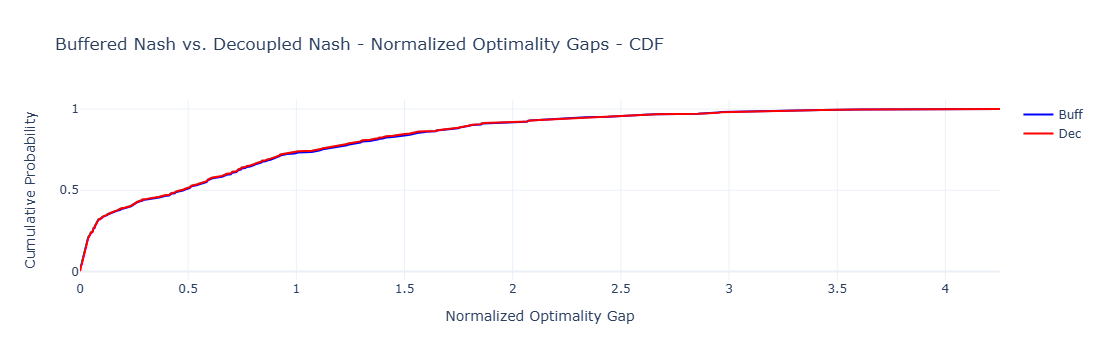

In [59]:
import itertools
with open('../sim_res/buff/gaps_stats_with_nash_data.pkl', 'rb') as f:
    gaps_stats_with_nash_data = pickle.load(f)


buff_nash_gaps = list(itertools.chain(*gaps_stats_with_nash_data['buff_nash_gaps']))
# buff_nash_gaps = [min(gaps) for gaps in gaps_stats_with_nash_data['buff_nash_gaps']]
dec_nash_gaps = list(itertools.chain(*gaps_stats_with_nash_data['dec_nash_gaps']))
# dec_nash_gaps = [min(gaps) for gaps in gaps_stats_with_nash_data['dec_nash_gaps']]

# Compute CDFs
buff_gaps_normalized_sorted = np.sort(buff_nash_gaps)
dec_gaps_normalized_sorted = np.sort(dec_nash_gaps)

cdf1 = np.arange(1, len(buff_gaps_normalized_sorted) + 1) / len(buff_gaps_normalized_sorted)
cdf2 = np.arange(1, len(dec_gaps_normalized_sorted) + 1) / len(dec_gaps_normalized_sorted)

# Create figure
fig = go.Figure()

fig.add_trace(go.Scatter(x=buff_gaps_normalized_sorted, y=cdf1, mode='lines', name="Buff", line=dict(color='blue')))
fig.add_trace(go.Scatter(x=dec_gaps_normalized_sorted, y=cdf2, mode='lines', name="Dec", line=dict(color='red')))

# Layout
fig.update_layout(title="Buffered Nash vs. Decoupled Nash - Normalized Optimality Gaps - CDF",
                  xaxis_title="Normalized Optimality Gap",
                  yaxis_title="Cumulative Probability",
                  template="plotly_white")

# Show figure
fig.show()
